# Gamma/neutron discrimination based on ML
---
## Machine learning - Training and compression
---
- Workflow based on R. S. Molina, I. R. Morales, M. L. Crespo, V. G. Costa, S. Carrato and G. Ramponi, "An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA", in IEEE Embedded Systems Letters, vol. 16, no. 3, pp. 255-258, Sept. 2024, doi: 10.1109/LES.2023.3343030.
- Code adapted from the official repository of "An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA"
- Using open dataset from: https://doi.org/10.5281/zenodo.8037058

## Import libraries


In [1]:
import os
import numpy as np
from numpy import array
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd

# Tensorflow + Keras libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.regularizers import l2, l1

import tensorflow_model_optimization as tfmot

## Pruning
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning

## Quantization
from qkeras import *

## Knowlege distillation
from src.distillationClassKeras import *

## Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

# Pre-processing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

## Training
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)

In [2]:
# import tensorflow as tf 
physical_devices = tf.config.list_physical_devices('GPU') 
print("Num GPUs Available: ", len(physical_devices))
print("Available devices: ", physical_devices)

# for device in physical_devices:
#     tf.config.experimental.set_memory_growth(device, True)

Num GPUs Available:  0
Available devices:  []


### Auxiliar functions

In [3]:
# Function to define the training and testing datasets

def preproc_dataset_(signal_dfN, signal_dfG):
    # Label in csv file corresponds to the signal class
    _LABEL_COLUMN = 'class'

    dfTest  = pd.DataFrame()
    dfTrain = pd.DataFrame()

    signal_dfN = shuffle(signal_dfN)
    signal_dfG = shuffle(signal_dfG)

    signal_df = pd.concat([signal_dfN, signal_dfG])

    for k in range(0,2):
        df2 = signal_df[signal_df[_LABEL_COLUMN].isin([k])]

        df_tr = df2[:10000]
        df_t  = df2[10001:10900]

        dfTrain = pd.concat([df_tr, dfTrain])
        dfTest  = pd.concat([df_t, dfTest])
    
    return dfTrain, dfTest

### Dataset

In [4]:
# Define path 

PATH = 'dataset/'

GAMMA_DATASET_FILE   = PATH + 'gamma_label.csv'
NEUTRON_DATASET_FILE = PATH + 'neutron_label.csv'

TEST_DATASET_FILE = PATH + 'test.csv'

In [5]:
# Load datasets in Pandas data frame

dfGamma   = pd.read_csv(GAMMA_DATASET_FILE)
dfNeutron = pd.read_csv(NEUTRON_DATASET_FILE)
dfTestGN  = pd.read_csv(TEST_DATASET_FILE)

In [6]:
# Explore the data frame
dfGamma

,120,121,122,123,124,125,126,127,128,129,...,272,273,274,275,276,277,278,279,280,class
0,403,403,403,403,403,403,403,403,403,403,...,364,365,363,364,362,363,364,363,364,0
1,402,402,403,402,402,402,403,403,402,403,...,361,360,361,360,360,360,360,361,360,0
2,403,403,404,403,403,403,404,402,402,403,...,330,329,330,327,329,329,329,329,329,0
3,403,405,403,403,402,403,402,401,400,400,...,385,386,385,385,385,386,384,384,384,0
4,404,403,403,403,403,403,403,402,402,402,...,385,384,384,385,383,384,383,384,383,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10908,378,377,376,376,375,374,375,374,374,373,...,364,364,364,363,365,363,364,363,364,0
10909,387,386,387,384,384,383,382,381,381,379,...,354,353,352,353,353,353,354,353,353,0
10910,385,385,385,385,384,384,384,385,385,385,...,195,196,196,196,197,196,197,196,198,0
10911,388,388,388,388,389,388,387,387,386,384,...,323,322,324,322,324,323,322,321,323,0


In [7]:
# Pre-processing dataset for training
df_train, dfTest = preproc_dataset_(dfNeutron, dfGamma)

# Save the test
# dfTest.to_csv('dataset/test.csv')

In [8]:
df_train_ = df_train.pop('class')
dfTest_   = dfTest.pop('class')

# One-hot encoder
le = LabelEncoder()
y = le.fit_transform(df_train_)
y = to_categorical(df_train_, 2)

le = LabelEncoder()
yTest = le.fit_transform(dfTest_)
yTest = to_categorical(dfTest_, 2)

# Split training dataset into training and validation
x_train, x_val, y_train, y_val = train_test_split(df_train, y, test_size=0.3, random_state=42)

In [9]:
# Exploration of the training dataset
df_train

,120,121,122,123,124,125,126,127,128,129,...,271,272,273,274,275,276,277,278,279,280
26647,386,386,385,385,387,386,385,386,386,386,...,56,54,54,55,54,54,53,56,53,54
17030,385,384,385,385,385,384,385,385,384,384,...,50,49,50,49,48,50,49,48,49,47
23717,386,384,385,386,384,386,384,385,385,385,...,48,49,48,48,50,49,49,50,50,51
8083,403,402,403,404,403,404,403,404,403,403,...,77,75,76,76,75,76,75,76,75,75
14454,405,404,406,404,404,404,404,405,404,405,...,66,65,64,63,61,61,61,61,60,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6798,499,500,500,499,500,499,499,499,498,497,...,479,479,479,479,478,479,478,479,479,480
3699,403,403,404,404,405,404,403,403,401,400,...,377,377,377,376,376,377,377,376,375,376
6714,500,501,501,501,501,502,501,501,501,501,...,446,445,445,447,445,445,446,446,445,447
5456,499,499,498,497,496,496,497,495,495,493,...,485,485,485,485,485,485,484,484,483,484


##  Machine leraning - Training and compression


 **Pruning** is a technique used to reduce the size and complexity of a deep learning model by removing unnecessary weights or neurons. Its main goal is to improve the model's efficiency by reducing memory consumption and speeding up inference, without significantly affecting its performance. 
 
 **Quantization** is a technique that reduces the numerical precision of a neural network’s parameters by converting floating-point values (e.g., 32-bit) to lower-precision representations, such as 16-bit or even 8-bit. The main goal is to reduce the model size and speed up inference, especially on resource-constrained devices like mobile phones or microcontrollers.

In this lab, we will use **quantization-aware training** (QAT) and **quantization-aware pruning** (QAP).

**QAT** is a training technique where the model learns to adapt to quantization before being deployed on hardware. Instead of training the model in full precision (32-bit floating point) and then quantizing it, quantization is introduced during training.

**QAP** combines pruning (removal of unnecessary connections in the neural network) with quantization-aware training. The goal is to reduce the model size before quantization to obtain a more efficient network without sacrificing accuracy.

### Knowledge distillation
 
To obtain the reduced model that will be deployed onto the FPGA (hereinafter referred to as the student), **knowledge distillation** (KD) learning approach will be employed. This method involves the teacher model transferring its knowledge to the student model. The overall technique is summarized in the following figure. 

For more information about KD: Hinton, G. (2015). Distilling the Knowledge in a Neural Network. arXiv preprint arXiv:1503.02531.

### Teacher training

In [10]:
# Define the hyperparameters for the teacher model

lr = 0.001
neurons_teacher = [10, 5, 7, 5, 6]

In [11]:
# This function defines the teacher architecture composed of six dense layers.
# bestHP contains the number of neurons per each dense layer.

def teacher_topology(bestHP):

    teacher = keras.Sequential(
        [
            keras.Input(shape=(161, )),

            Dense(bestHP[0], name='fc1', input_shape=(161,), kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu1'),

            Dense(bestHP[1], name='fc2', kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu2'),

            Dense(bestHP[2], name='fc3', kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu3'),
            Dropout(0.1),

            Dense(bestHP[3], name='fc4', kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu4'),
            Dropout(0.2),

            Dense(bestHP[4], name='fc5'),
            Activation(activation='relu', name='relu5'),
            Dropout(0.2),

            Dense(2, name='output'),
            Activation(activation='sigmoid', name='activationOutput'),

        ],
        name="teacher_MLP",
    )

    teacher.summary()

    return teacher

### Build teacher model

This function defines the teacher model's topology by calling the teacher_topology()function, sets the optimizer to Adam with the corresponding learning rate, and set the model's configuration using binary_crossentropy as the loss function and accuracy as the evaluation metric.

In [19]:
def build_teacher(neurons_teacher):
    model = teacher_topology(neurons_teacher)
    opt = Adam(lr)
    model.compile(optimizer=opt, loss=['binary_crossentropy'], metrics=['accuracy'])
    return model

In [20]:
teacher_model = build_teacher(neurons_teacher)

Model: "teacher_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (Dense)                 (None, 10)                1620      
                                                                 
 relu1 (Activation)          (None, 10)                0         
                                                                 
 fc2 (Dense)                 (None, 5)                 55        
                                                                 
 relu2 (Activation)          (None, 5)                 0         
                                                                 
 fc3 (Dense)                 (None, 7)                 42        
                                                                 
 relu3 (Activation)          (None, 7)                 0         
                                                                 
 dropout_3 (Dropout)         (None, 7)                 

### Training of the teacher model

In [28]:
callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor='val:loss', patience=10, verbose=1, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='accuracy', factor=0.4, patience=3, verbose=1)
            ]

history_teacher = teacher_model.fit(x=x_train, y=y_train,
                                    validation_data=(x_val, y_val),
                                    batch_size=64,
                                    epochs=50,
                                    callbacks=[callbacks],
                                    verbose=1
                                    )

Epoch 1/50
219/219 [==============================] - 0s 2ms/step - loss: 0.1406 - accuracy: 0.9493 - val_loss: 0.0484 - val_accuracy: 0.9935 - lr: 2.6844e-09
Epoch 2/50
219/219 [==============================] - 0s 2ms/step - loss: 0.1373 - accuracy: 0.9489 - val_loss: 0.0484 - val_accuracy: 0.9935 - lr: 2.6844e-09
Epoch 3/50
219/219 [==============================] - 0s 2ms/step - loss: 0.1352 - accuracy: 0.9519 - val_loss: 0.0484 - val_accuracy: 0.9935 - lr: 2.6844e-09
Epoch 4/50
219/219 [==============================] - 0s 2ms/step - loss: 0.1400 - accuracy: 0.9521 - val_loss: 0.0484 - val_accuracy: 0.9935 - lr: 2.6844e-09
Epoch 5/50
219/219 [==============================] - 0s 2ms/step - loss: 0.1387 - accuracy: 0.9519 - val_loss: 0.0484 - val_accuracy: 0.9935 - lr: 2.6844e-09
Epoch 6/50
219/219 [==============================] - 0s 2ms/step - loss: 0.1437 - accuracy: 0.9496 - val_loss: 0.0484 - val_accuracy: 0.9935 - lr: 2.6844e-09
Epoch 7/50
196/219 [=========================>

### Plot accuracy and loss

Plots of the behavior of accuracy and loss during training are generated.

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])


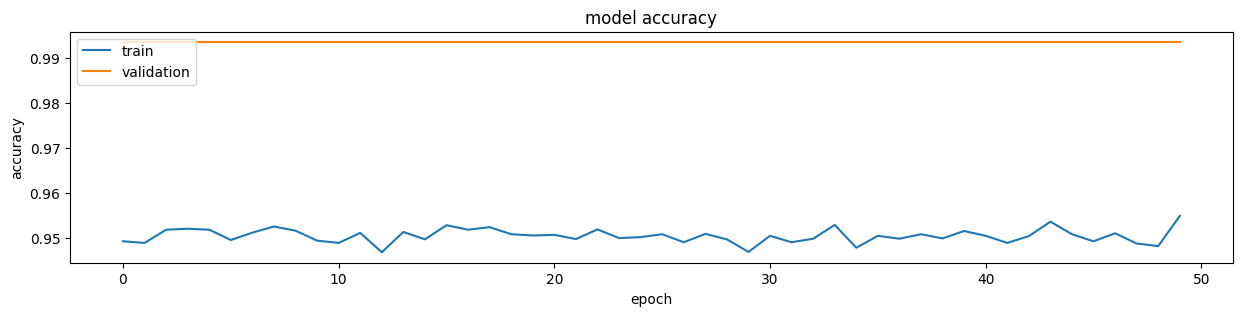

<Figure size 640x480 with 0 Axes>

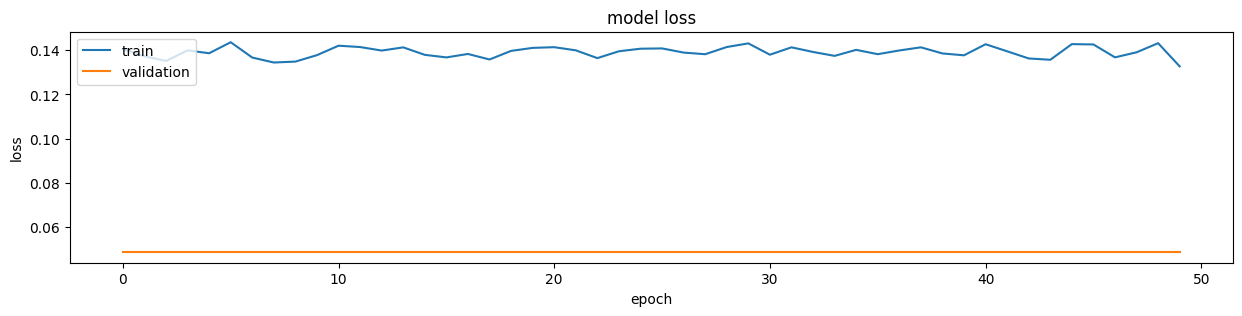

In [29]:
print(history_teacher.history.keys())

## Plot for accuracy
plt.figure(figsize=(15,3))
plt.plot(history_teacher.history['accuracy'])
plt.plot(history_teacher.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
plt.figure()

## Plot for loss
plt.figure(figsize=(15,3))
plt.plot(history_teacher.history['loss'])
plt.plot(history_teacher.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### Preformance analysis

57/57 [==============================] - 0s 789us/step


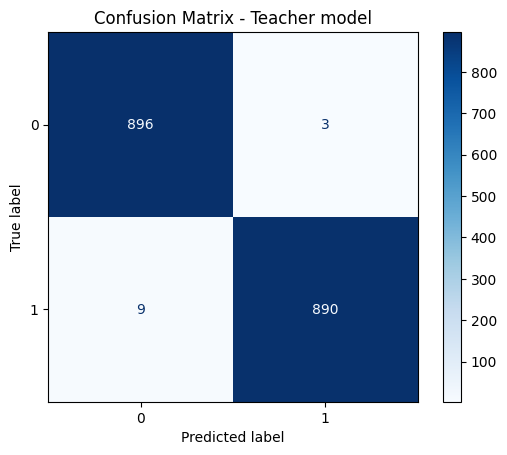

In [30]:
# Obtain the confusion matrix using the testing dataset 
y_pred_probs = teacher_model.predict(dfTest)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(yTest, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Teacher model')
plt.show()

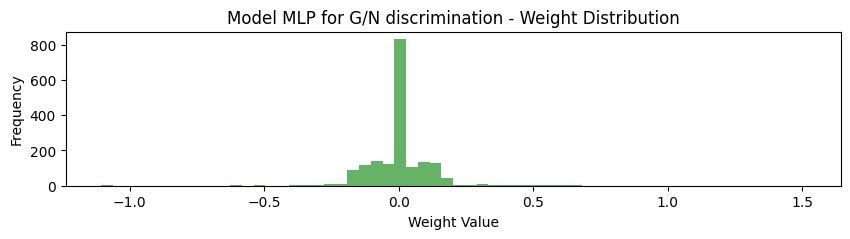

In [31]:
# Weight distribution

weights = np.concatenate([w.flatten() for w in teacher_model.get_weights()])

plt.figure(figsize=(10,2))
plt.hist(weights, bins=60, color='green', alpha=0.6)
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.title("Model MLP for G/N discrimination - Weight Distribution")
plt.show()

### Save teacher model

In [ ]:
# If needed, save the teacher model [uncomment the following line]
# teacher_model.save('models/teacherModel_GN_smr4078.h5')

---

### Pruning

In [32]:
epochs = 16
lr = 0.001
loss = 'categorical_crossentropy'
op = Adam(lr)
metrics = ['accuracy']
batch = 32
val_split = 0.2

final_sparsity = 0.5

pruning_params = {
                 'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
                     initial_sparsity=0, final_sparsity=final_sparsity, begin_step=0, end_step=3000
                 )
                 }

callbacks.append(pruning_callbacks.UpdatePruningStep())

In [33]:
modelP = tfmot.sparsity.keras.prune_low_magnitude(teacher_model, **pruning_params)
modelP.compile(optimizer=op, loss=loss, metrics=metrics)

In [34]:
history_P = modelP.fit(x=x_train, y=y_train,
                       validation_split=val_split,
                       batch_size=64, 
                       epochs=32,
                       callbacks= [callbacks],
                       verbose=1
                       )

Epoch 1/32
175/175 [==============================] - 4s 3ms/step - loss: 0.1776 - accuracy: 0.9421 - val_loss: 0.0523 - val_accuracy: 0.9839 - lr: 0.0010
Epoch 2/32
175/175 [==============================] - 0s 2ms/step - loss: 0.1494 - accuracy: 0.9313 - val_loss: 0.0698 - val_accuracy: 0.9664 - lr: 0.0010
Epoch 3/32
175/175 [==============================] - 0s 3ms/step - loss: 0.1651 - accuracy: 0.9426 - val_loss: 0.0494 - val_accuracy: 0.9936 - lr: 0.0010
Epoch 4/32
175/175 [==============================] - 0s 2ms/step - loss: 0.1402 - accuracy: 0.9599 - val_loss: 0.0369 - val_accuracy: 0.9936 - lr: 0.0010
Epoch 5/32
175/175 [==============================] - 0s 2ms/step - loss: 0.1311 - accuracy: 0.9562 - val_loss: 0.0376 - val_accuracy: 0.9921 - lr: 0.0010
Epoch 6/32
175/175 [==============================] - 0s 2ms/step - loss: 0.1196 - accuracy: 0.9609 - val_loss: 0.0941 - val_accuracy: 0.9386 - lr: 0.0010
Epoch 7/32
175/175 [==============================] - 0s 2ms/step - lo

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])


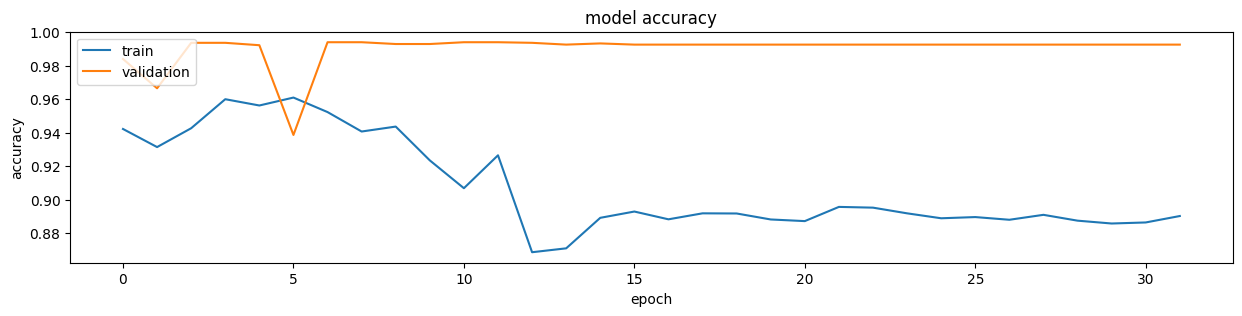

<Figure size 640x480 with 0 Axes>

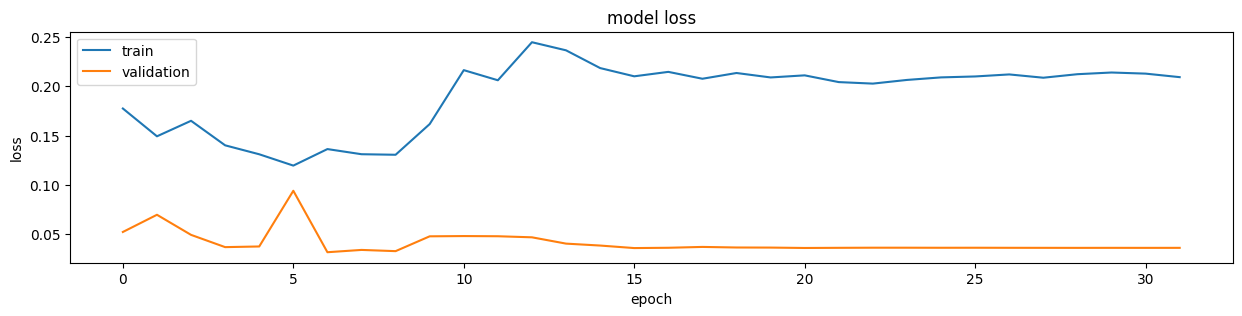

In [35]:
print(history_P.history.keys())

## Plot for accuracy
plt.figure(figsize=(15,3))
plt.plot(history_P.history['accuracy'])
plt.plot(history_P.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
plt.figure()

## Plot for loss
plt.figure(figsize=(15,3))
plt.plot(history_P.history['loss'])
plt.plot(history_P.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### Confusion matrix - Pruning

57/57 [==============================] - 0s 991us/step


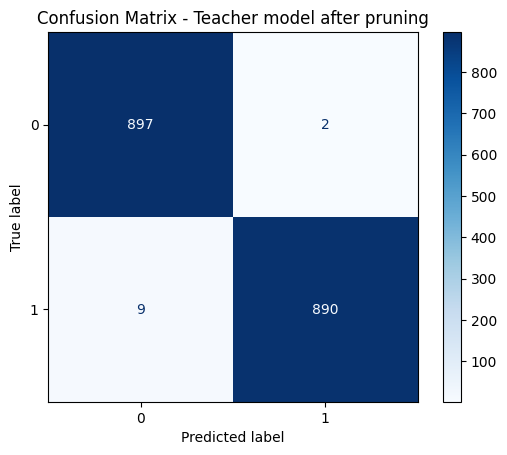

In [36]:
# Obtain the confusion matrix using the testing dataset 
y_pred_probs = modelP.predict(dfTest)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(yTest, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Teacher model after pruning')
plt.show()

### Quantization-aware training (QAT)

In [37]:
## Estrategia de cuantizacion

## Definicion del numero de bits para kernel, bias, y activacion.
# 8-bits

kernelQ      = "quantized_bits(8,4,alpha=1)"
biasQ        = "quantized_bits(8,4,alpha=1)"
activationQ  = "quantized_bits(8,4)"

modelQAT = Sequential(
                [
                    QDense(neurons_teacher[0], name='input', input_shape=(161,),
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu0'),
                    # Dropout(0.1),

                    QDense(neurons_teacher[1], name='fc1', 
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu1'),
                    # Dropout(0.1),

                    QDense(neurons_teacher[2], name='fc2',
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu2'),
                    Dropout(0.1),

                    QDense(neurons_teacher[3], name='fc3',
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu3'), 
                    Dropout(0.2),
                
                    QDense(neurons_teacher[4], name='fc4',
                           kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                           kernel_initializer='lecun_uniform'),
                    QActivation(activation=activationQ, name='relu4'), 
                    Dropout(0.2),
                
                    QDense(2, name='output',
                           kernel_quantizer= kernelQ, bias_quantizer= biasQ,
                           kernel_initializer='lecun_uniform'),
                    Activation(activation='sigmoid', name='sigmoid')       

                ],

                name="quantizedModel",
)

In [39]:
modelQAT.summary()

Model: "quantizedModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (QDense)              (None, 10)                1620      
                                                                 
 relu0 (QActivation)         (None, 10)                0         
                                                                 
 fc1 (QDense)                (None, 5)                 55        
                                                                 
 relu1 (QActivation)         (None, 5)                 0         
                                                                 
 fc2 (QDense)                (None, 7)                 42        
                                                                 
 relu2 (QActivation)         (None, 7)                 0         
                                                                 
 dropout_6 (Dropout)         (None, 7)              

In [40]:
# Model Training

epochs = 16
lr = 0.0001
loss = 'binary_crossentropy'
op = Adam(lr)
metrics = ['accuracy']
batch = 32
val_split = 0.2


modelQAT.compile(optimizer=op, loss=loss, metrics=metrics)
                
historyQAT = modelQAT.fit(x=x_train, y=y_train,
                          validation_split = val_split,
                          epochs=epochs,
                          batch_size = batch,
                          verbose=1
                          )

Epoch 1/16
350/350 [==============================] - 2s 3ms/step - loss: 0.5544 - accuracy: 0.9206 - val_loss: 0.0440 - val_accuracy: 0.9929
Epoch 2/16
350/350 [==============================] - 1s 2ms/step - loss: 0.3226 - accuracy: 0.9330 - val_loss: 0.0476 - val_accuracy: 0.9925
Epoch 3/16
350/350 [==============================] - 1s 2ms/step - loss: 0.2092 - accuracy: 0.9549 - val_loss: 0.0539 - val_accuracy: 0.9896
Epoch 4/16
350/350 [==============================] - 1s 1ms/step - loss: 0.1728 - accuracy: 0.9659 - val_loss: 0.0490 - val_accuracy: 0.9932
Epoch 5/16
350/350 [==============================] - 1s 1ms/step - loss: 0.1649 - accuracy: 0.9669 - val_loss: 0.0593 - val_accuracy: 0.9932
Epoch 6/16
350/350 [==============================] - 1s 2ms/step - loss: 0.1491 - accuracy: 0.9688 - val_loss: 0.1342 - val_accuracy: 0.9504
Epoch 7/16
350/350 [==============================] - 1s 2ms/step - loss: 0.1344 - accuracy: 0.9712 - val_loss: 0.0606 - val_accuracy: 0.9929
Epoch 

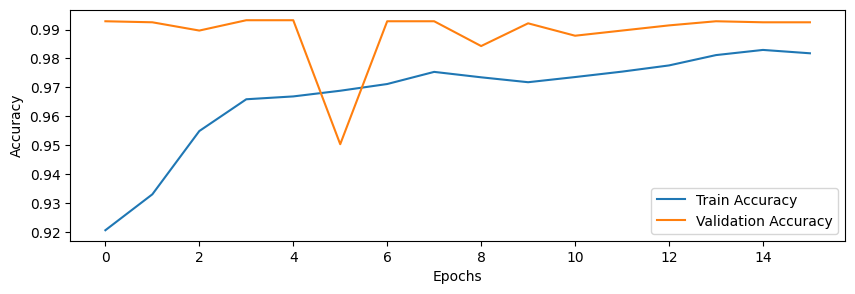

In [41]:
# Plot accuracy over epochs
plt.figure(figsize=(10,3))
plt.plot(historyQAT.history['accuracy'], label='Train Accuracy')
plt.plot(historyQAT.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Confusion matrix QAT

57/57 [==============================] - 0s 1ms/step


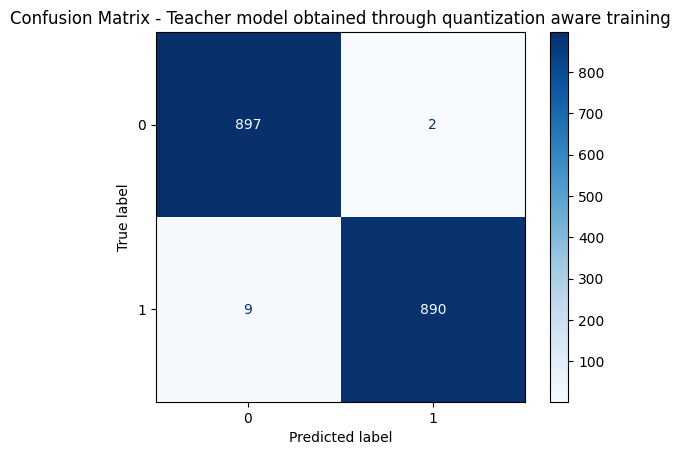

In [43]:
# Obtain the confusion matrix using the testing dataset 
y_pred_probs = modelQAT.predict(dfTest)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(yTest, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Teacher model obtained through quantization aware training')
plt.show()

### Student training

To obtain the reduced model that will be deployed onto the FPGA (hereinafter referred to as the student network), a **KD** learning approach will be employed. This method involves the teacher model transferring its knowledge to the student model. The latter is defined using quantization and pruning strategies.  
 
In this project, the number of bits was set to eight, and the target sparsity was set to 50%. 
 
**Qkeras** is employed to define the student model in a quantized manner. 
 
**For more information regarding QKeras**: Coelho, C. N., Kuusela, A., Zhuang, H., Aarrestad, T., Loncar, V., Ngadiuba, J., ... & Summers, S. (2020). Ultra low-latency, low-area inference accelerators using heterogeneous deep quantization with QKeras and hls4ml. arXiv preprint arXiv:2006.10159, 108.

### Hyperparameters for the student model

In [44]:
# Define the hyperparameters for the student model
lr = 0.001
neurons_student = [6, 4, 2, 4, 3]

In [45]:
def student_topology(neurons_student):
    
    '''
    Model to be trained. Defined with quantization strategies. 
    Input: hyperparams. (bestHP)
    Output: compressed model (studentQ_MLP). 

    '''
    ######## ---------------------------  Model definition - 1D STUDENT -----------------------------------------

    # Number of bits 
    ## 4-bits
    kernelQ_4b = "quantized_bits(4,2,alpha=1)"
    biasQ_4b = "quantized_bits(4,2,alpha=1)"
    activationQ_4b = 'quantized_bits(4, 0)'

    ## 8-bits
    kernelQ = "quantized_bits(8,4,alpha=1)"
    biasQ = "quantized_bits(8,4,alpha=1)"
    activationQ = 'quantized_bits(8)'
    
    ## 16-bits
    kernelQ_16b = "quantized_bits(16,6,alpha=1)"
    biasQ_16b = "quantized_bits(16,6,alpha=1)"
    activationQ_16b = 'quantized_bits(16)'
    
    studentQ_MLP = keras.Sequential(
            [   
                Input(shape=(161,), name='inputLayer'),
                QDense(neurons_student[0], name='fc1',
                        kernel_quantizer= kernelQ, bias_quantizer= biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation= activationQ ,  name='relu0'),
                Dropout(0.1),
                    
                QDense(neurons_student[1], name='fc2',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu1'), 
                Dropout(0.1),
                

                QDense(neurons_student[2], name='fc3',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu2'), 
                Dropout(0.1),

                QDense(neurons_student[3], name='fc4',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu3'), 
                Dropout(0.2),

                QDense(neurons_student[4], name='fc5',
                       kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                       kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu4'), 
                Dropout(0.2),
               
                QDense(2, name='output',
                        kernel_quantizer= kernelQ_16b, bias_quantizer= biasQ_16b,
                        kernel_initializer='lecun_uniform'),
                Activation(activation='sigmoid', name='outputActivation')

                
            ],
            name="studentMLP",
        )


    return studentQ_MLP

###  Build student model

In [46]:
# Build student model with pruning strategy

def build_student(student_neurons):

    '''
    Model to be compressed. Defined with quantization strategies. 
    Input: hyperparams (student_neurons).
    Output: compressed model (studentQ). 

    '''
    
    qmodel = student_topology(student_neurons)

    # Pruning parameters 
    pruning_params = {
        'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0, final_sparsity=0.5, begin_step=0, end_step=1000
    )
    }
    
    studentQ = prune.prune_low_magnitude(qmodel, **pruning_params)
    
    
    return studentQ

###  Compile student model for knowledge distillation + QAT

In [47]:
studentQ = build_student(neurons_student)

distilled_student = Distiller(student=studentQ, teacher=teacher_model)

adam = Adam(lr)

train_labels = np.argmax(y_train, axis=1)

distilled_student.compile(
        optimizer=adam,
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
        student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        distillation_loss_fn=keras.losses.KLDivergence(),
        alpha=0.1, 
        temperature=10,
    )

###  Training of the student model

In [48]:
callbacks = [
                tf.keras.callbacks.EarlyStopping(patience=10, verbose=1),
                tf.keras.callbacks.ReduceLROnPlateau(monitor='accuracy', factor=0.3, patience=3, verbose=1),
                ]  

callbacks.append(pruning_callbacks.UpdatePruningStep())

history_studentQPKD = distilled_student.fit(x_train, train_labels, 
                               batch_size = 64, 
                               epochs= 32, 
                               validation_split=0.2,
                               callbacks = callbacks
                               )

Epoch 1/32


c:\GitHub\KRIA_Starter_Guide\ICTP_MachineLearning\neuenv\lib\site-packages\keras\backend.py:5612: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


152/175 [=========================>....] - ETA: 0s - sparse_categorical_accuracy: 0.7118 - student_loss: 0.6018 - distillation_loss: 5.6390e-04WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: sparse_categorical_accuracy,student_loss,distillation_loss,val_sparse_categorical_accuracy,val_student_loss


c:\GitHub\KRIA_Starter_Guide\ICTP_MachineLearning\neuenv\lib\site-packages\keras\backend.py:5612: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


175/175 [==============================] - 5s 5ms/step - sparse_categorical_accuracy: 0.7179 - student_loss: 0.5939 - distillation_loss: 5.5573e-04 - val_sparse_categorical_accuracy: 0.8432 - val_student_loss: 0.4696 - lr: 0.0010
Epoch 2/32
175/175 [==============================] - 0s 3ms/step - sparse_categorical_accuracy: 0.7904 - student_loss: 0.4927 - distillation_loss: 4.4227e-04 - val_sparse_categorical_accuracy: 0.8293 - val_student_loss: 0.4334 - lr: 0.0010
Epoch 3/32
175/175 [==============================] - 0s 2ms/step - sparse_categorical_accuracy: 0.8042 - student_loss: 0.4648 - distillation_loss: 4.0204e-04 - val_sparse_categorical_accuracy: 0.8775 - val_student_loss: 0.3517 - lr: 0.0010
Epoch 4/32
175/175 [==============================] - 0s 3ms/step - sparse_categorical_accuracy: 0.8238 - student_loss: 0.4367 - distillation_loss: 3.6917e-04 - val_sparse_categorical_accuracy: 0.8729 - val_student_loss: 0.3467 - lr: 0.0010
Epoch 5/32
175/175 [===========================

###  Performance analysis

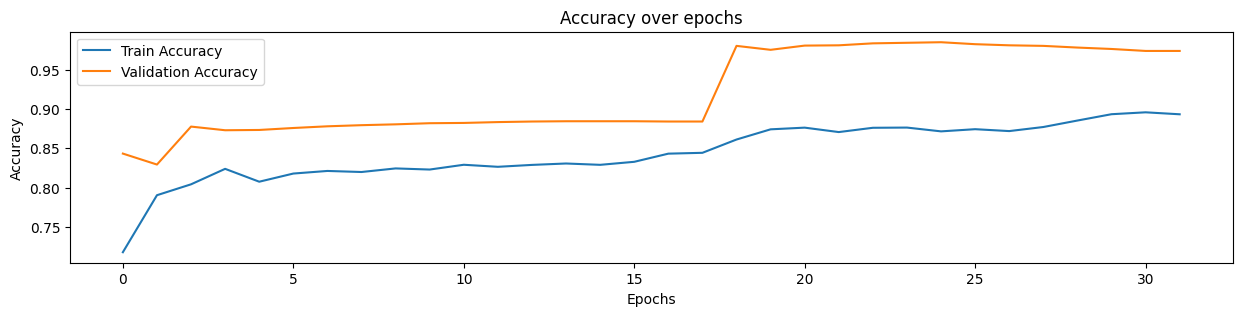

In [ ]:
# Plot accuracy over epochs
plt.figure(figsize=(15,3))
plt.plot(history_studentQPKD.history['sparse_categorical_accuracy'], label='Train Accuracy')
plt.plot(history_studentQPKD.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

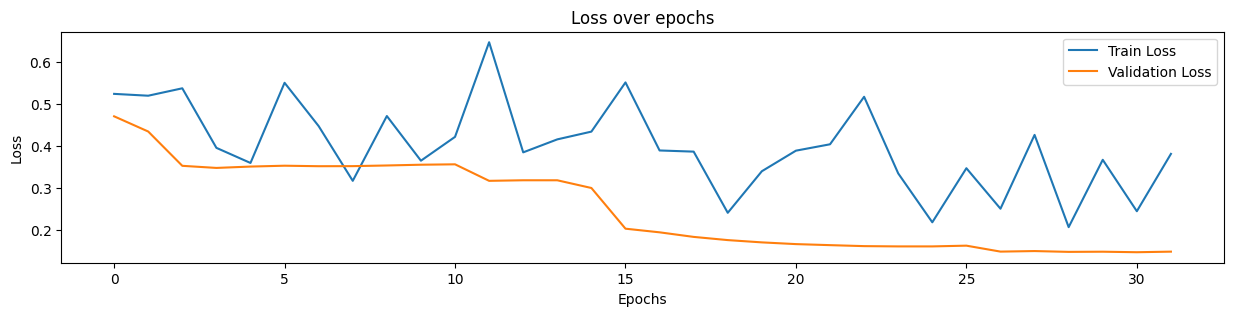

In [50]:
# Plot loss over epochs
plt.figure(figsize=(15,3))
plt.plot(history_studentQPKD.history['student_loss'], label='Train Loss')
plt.plot(history_studentQPKD.history['val_student_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over epochs')
plt.show()

57/57 [==============================] - 0s 1ms/step


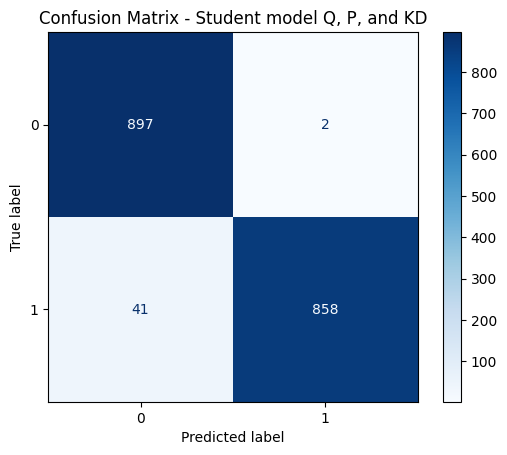

In [51]:
# Obtain the confusion matrix using the testing dataset 
y_pred_probs = distilled_student.student.predict(dfTest)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(yTest, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Student model Q, P, and KD')
plt.show()

### Test single prediction

Test the model for single inputs. 

The variable indexPrediction corresponds to the signals' index  in the testing dataset. You can change this number to observe how the ML-based model predicts for specific inputs.

1/1 [==============================] - 0s 23ms/step
> Input [1. 0.] -> Predicted = [[0.6260242  0.07043161]] | 


Text(0.5, 1.0, 'Signal used for inference - Pulse: 1500, Label: [1. 0.], Prediction: [[0.6260242  0.07043161]]')

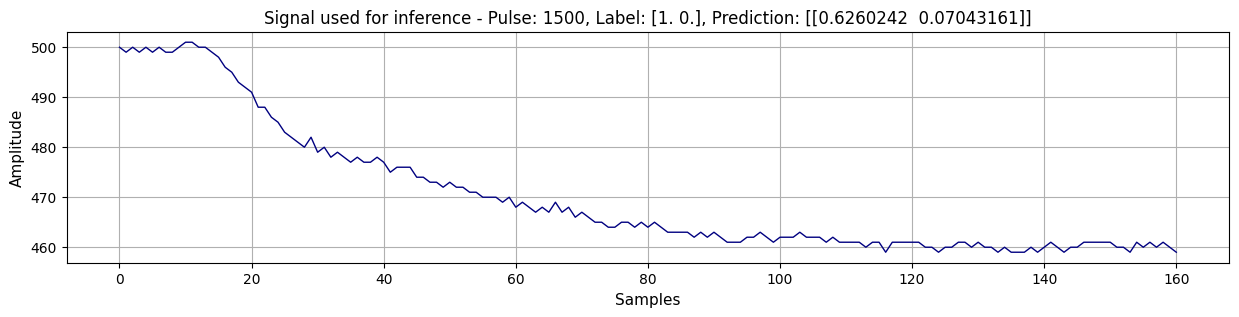

In [52]:
# Index of the signal in the testing dataset
indexPrediction = 1500

x_input = dfTest.iloc[indexPrediction]
y_label = yTest[indexPrediction]

inputPred = array([x_input])

y_pred = distilled_student.student.predict(inputPred) 
print("> Input %s -> Predicted = %s | " % (y_label, y_pred))

plt.figure(figsize=(15,3))
plt.xlabel('Samples', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.grid(True, alpha=1.0)
plt.plot(x_input.values,  label="Signal 1", color='navy', markersize=7, lw=1)

plt.title('Signal used for inference - Pulse: %s, Label: %s, Prediction: %s' % (indexPrediction, y_label, y_pred))

### Save student model

In [ ]:
model = strip_pruning(distilled_student.student)
model.summary()

# model.save('models/studentModel_GN_smr4078.h5')

Model: "studentMLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (QDense)                (None, 6)                 972       
                                                                 
 relu0 (QActivation)         (None, 6)                 0         
                                                                 
 dropout_9 (Dropout)         (None, 6)                 0         
                                                                 
 fc2 (QDense)                (None, 4)                 28        
                                                                 
 relu1 (QActivation)         (None, 4)                 0         
                                                                 
 dropout_10 (Dropout)        (None, 4)                 0         
                                                                 
 fc3 (QDense)                (None, 2)                 1